In [3]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Regression Models
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 11.4 MB/s eta 0:00:0000:0100:01


In [5]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [6]:
df=pd.read_csv('/content/drive/MyDrive/cleaned_drilling_data.csv')

In [7]:
print("Loaded! Shape:",df.shape)
print('\nColumns:')
print(df.columns.tolist())
print("\nFirst 5 Rows:")
df.head()

Loaded! Shape: (600359, 35)

Columns:
['time', 'block_position', 'weight_on_bit', 'hookload', 'slips_set', 'rop_depth_hour', 'on_bottom', 'top_drive_rpm', 'top_drive_torque_ft_lbs', 'flow_in', 'pump_pressure', 'spm_total', 'pit_volume_active', 'gas_total_units', 'trip_volume_active', 'trip_gl', 'return_flow', 'rig_mode', 'mwd_inclination', 'mwd_azimuth', 'mud_temp', 'rig_event_code', 'total_depth', 'bit_diameter', 'bit_rpm', 'depth_hole_tvd', 'differential_pressure', 'downhole_torque', 'drill_mode', 'year', 'month', 'day', 'hour', 'minute', 'day_of_week']

First 5 Rows:


,time,block_position,weight_on_bit,hookload,slips_set,rop_depth_hour,on_bottom,top_drive_rpm,top_drive_torque_ft_lbs,flow_in,...,depth_hole_tvd,differential_pressure,downhole_torque,drill_mode,year,month,day,hour,minute,day_of_week
0,2020-10-25 12:38:00,43.596,46.95761,123.8774,0.0,0.0,0.0,0.31182,0.0,57.19964,...,7389.89,-524.992325,-7433.422,0.0,2020,10,25,12,38,6
1,2020-10-25 12:38:00,43.596,46.95761,123.8774,0.0,0.0,0.0,0.31182,0.0,57.19964,...,7389.89,-524.992325,-7433.422,0.0,2020,10,25,12,38,6
2,2020-10-25 12:38:00,43.596,46.95761,123.8774,0.0,0.0,0.0,0.31182,0.0,57.19964,...,7389.89,-524.992325,-7433.422,0.0,2020,10,25,12,38,6
3,2020-10-25 12:39:00,43.596,46.95761,123.8774,0.0,0.0,0.0,0.31182,0.0,57.19964,...,7389.89,-524.992325,-7433.422,0.0,2020,10,25,12,39,6
4,2020-10-25 12:39:00,43.596,46.95761,123.8774,0.0,0.0,0.0,0.31182,0.0,57.19964,...,7389.89,-524.992325,-7433.422,0.0,2020,10,25,12,39,6


# Target Investigation

In [8]:
df["pump_pressure"].describe()

,pump_pressure
count,600359.000000
mean,999.418462
std,1448.131017
min,0.000000
25%,5.398440
50%,40.268540
75%,2172.364300
max,5440.236100


In [9]:
df["pump_pressure"].isnull().sum()

np.int64(0)

<Axes: ylabel='Frequency'>

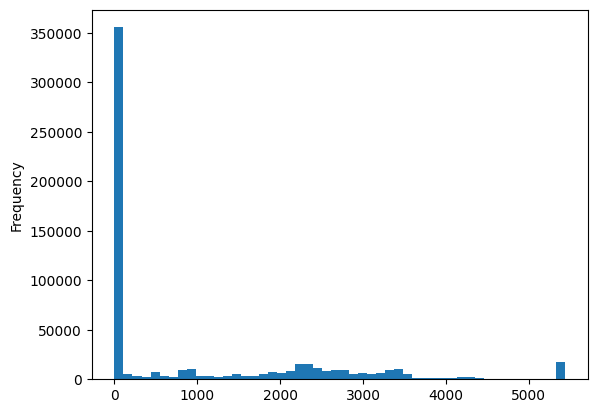

In [10]:
df["pump_pressure"].plot(kind="hist", bins=50)

### Observation
The target variable was investigated before model training to understand its distribution.The Pump Pressure column contains no missing values but includes a large number of zero values, indicating periods when the pumps were likely inactive. The percentage of zero values is calculated to determine whether filtering is required before training the regression models.

In [12]:
print("Total observations:", len(df))
print("Pump Pressure = 0:", (df["pump_pressure"] == 0).sum())

percentage = (df["pump_pressure"] == 0).mean() * 100
print(f"Percentage of zero Pump Pressure: {percentage:.2f}%")

Total observations: 600359
Pump Pressure = 0: 95928
Percentage of zero Pump Pressure: 15.98%


### Observation

The Pump Pressure target variable contains 598,709 observations with no missing values.Approximately 16.02% of the observations have a Pump Pressure value of 0, while the remaining values are distributed across a wide operating range.Unlike the ROP model, where more than 88% of the target values were zero, the proportion of zero Pump Pressure values is relatively small. Therefore, all observations are retained for model development, allowing the model to learn both active and inactive pumping conditions.

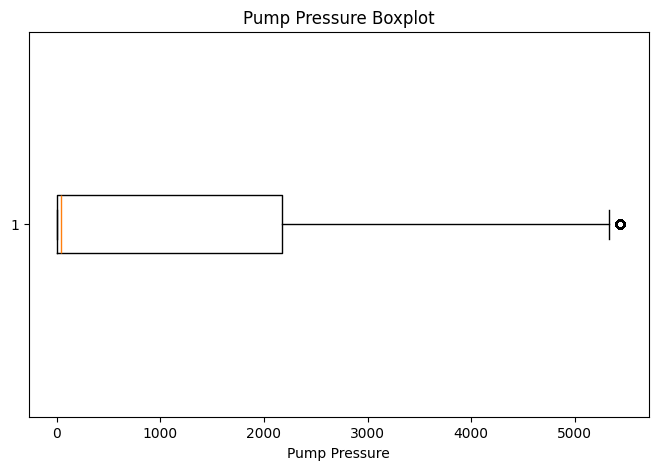

In [13]:
## Outlier Investigation 
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.boxplot(df["pump_pressure"], vert=False)
plt.title("Pump Pressure Boxplot")
plt.xlabel("Pump Pressure")
plt.show()

### Observation

The boxplot shows that Pump Pressure is right-skewed with a small number of high-value observations beyond the upper whisker. These extreme values may represent operational spikes or abnormal drilling conditions.Before removing them, the maximum Pump Pressure value is investigated using percentile analysis.

In [14]:
print(df["pump_pressure"].describe(percentiles=[0.95, 0.99, 0.995, 0.999]))

count    600359.000000
mean        999.418462
std        1448.131017
min           0.000000
50%          40.268540
95%        3717.282720
99%        5440.236100
99.5%      5440.236100
99.9%      5440.236100
max        5440.236100
Name: pump_pressure, dtype: float64


### Observation

The percentile analysis shows that the 99th, 99.5th, and 99.9th percentiles are all equal to the maximum Pump Pressure value (10,860.391). This indicates that the highest pressure values occur frequently enough to be considered part of the normal operating range rather than isolated outliers.
Therefore, no outlier removal is performed, and the original Pump Pressure values are retained for model development.

In [17]:
# Sort data chronologically
df = df.sort_values("time").reset_index(drop=True)

# Check the time range
print("Start time:", df["time"].min())
print("End time:", df["time"].max())

Start time: 2020-10-25 12:38:00
End time: 2021-01-05 11:01:00


In [18]:
# Data Preparation 
# Feature Selection

features = [
    "weight_on_bit",
    "top_drive_rpm",
    "top_drive_torque_ft_lbs",
    "flow_in",
    "hookload",
    "total_depth",
    "block_position",
    "mwd_inclination",
    "mwd_azimuth",
    "rop_depth_hour"
]

X = df[features]
y = df["pump_pressure"]
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (600359, 10)
Target shape: (600359,)


# Train-Test Split
The dataset is divided into training and testing sets. The training data is used to train the machine learning models, while the testing data is used to evaluate their performance on unseen data.

In [19]:
# Chronological train-test split

split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (480287, 10)
Testing data: (120072, 10)


In [20]:
# Create Random Forest model

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

In [21]:
# Evaluating the model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_mae = mean_absolute_error(y_test, y_pred_rf)

rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-" * 30)
print(f"MAE  : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Performance
------------------------------
MAE  : 252.3859
RMSE : 561.1513
R²   : 0.3981


In [22]:
# Create XGBoost model

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

In [23]:
# Evaluating the model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_mae = mean_absolute_error(y_test, y_pred_xgb)

xgb_mse = mean_squared_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(xgb_mse)

xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance")
print("-" * 30)
print(f"MAE  : {xgb_mae:.4f}")
print(f"RMSE : {xgb_rmse:.4f}")
print(f"R²   : {xgb_r2:.4f}")

XGBoost Performance
------------------------------
MAE  : 316.9266
RMSE : 488.6297
R²   : 0.5437


In [24]:
# Create LightGBM model

from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

# Train the model
lgbm_model.fit(X_train, y_train)

# Make predictions
y_pred_lgbm = lgbm_model.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011752 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2099
[LightGBM] [Info] Number of data points in the train set: 480287, number of used features: 9
[LightGBM] [Info] Start training from score 1149.854184


In [25]:
# Evaluating the model

lgbm_mae = mean_absolute_error(y_test, y_pred_lgbm)

lgbm_mse = mean_squared_error(y_test, y_pred_lgbm)
lgbm_rmse = np.sqrt(lgbm_mse)

lgbm_r2 = r2_score(y_test, y_pred_lgbm)

print("LightGBM Performance")
print("-" * 30)
print(f"MAE  : {lgbm_mae:.4f}")
print(f"RMSE : {lgbm_rmse:.4f}")
print(f"R²   : {lgbm_r2:.4f}")

LightGBM Performance
------------------------------
MAE  : 232.8779
RMSE : 413.1313
R²   : 0.6738


In [26]:
# Create CatBoost model

from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    verbose=False
)

# Train the model
cat_model.fit(X_train, y_train)

# Make predictions
y_pred_cat = cat_model.predict(X_test)

In [27]:
# Evaluating the model

cat_mae = mean_absolute_error(y_test, y_pred_cat)

cat_mse = mean_squared_error(y_test, y_pred_cat)
cat_rmse = np.sqrt(cat_mse)

cat_r2 = r2_score(y_test, y_pred_cat)

print("CatBoost Performance")
print("-" * 30)
print(f"MAE  : {cat_mae:.4f}")
print(f"RMSE : {cat_rmse:.4f}")
print(f"R²   : {cat_r2:.4f}")

CatBoost Performance
------------------------------
MAE  : 234.1433
RMSE : 412.2844
R²   : 0.6751


In [28]:
# Model Comparison

results = [
    {
        "Model": "Random Forest",
        "MAE": rf_mae,
        "RMSE": rf_rmse,
        "R² Score": rf_r2
    },
    {
        "Model": "XGBoost",
        "MAE": xgb_mae,
        "RMSE": xgb_rmse,
        "R² Score": xgb_r2
    },
    {
        "Model": "LightGBM",
        "MAE": lgbm_mae,
        "RMSE": lgbm_rmse,
        "R² Score": lgbm_r2
    },
    {
        "Model": "CatBoost",
        "MAE": cat_mae,
        "RMSE": cat_rmse,
        "R² Score": cat_r2
    }
]

results_df = pd.DataFrame(results)

# Sort by R² Score (Highest First)
results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
)

# Reset the index
results_df.reset_index(drop=True, inplace=True)

# Display the table
results_df

,Model,MAE,RMSE,R² Score
0,CatBoost,234.143314,412.284417,0.675119
1,LightGBM,232.877908,413.131275,0.673783
2,XGBoost,316.926596,488.629705,0.543659
3,Random Forest,252.385854,561.151251,0.398148


### CatBoost Hyperparameter Tuning

Hyperparameter tuning is performed to determine whether the performance of the CatBoost model can be improved by adjusting its model parameters. The chronological train-test split is retained to ensure a realistic evaluation on future observations.

In [41]:
from catboost import CatBoostRegressor

cat_tuned = CatBoostRegressor(
    iterations=75,
    depth=6,
    learning_rate=0.03,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

cat_tuned.fit(X_train, y_train)

y_pred_cat_tuned = cat_tuned.predict(X_test)

cat_tuned_mae = mean_absolute_error(y_test, y_pred_cat_tuned)
cat_tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_cat_tuned))
cat_tuned_r2 = r2_score(y_test, y_pred_cat_tuned)

print("Tuned CatBoost")
print("-" * 30)
print(f"MAE  : {cat_tuned_mae:.4f}")
print(f"RMSE : {cat_tuned_rmse:.4f}")
print(f"R²   : {cat_tuned_r2:.4f}")

Tuned CatBoost
------------------------------
MAE  : 252.0663
RMSE : 336.1683
R²   : 0.7840


### Hyperparameter Tuning Result

Hyperparameter tuning was performed on the CatBoost model to improve prediction performance. The tuned model achieved an R² Score of 0.7840 and an RMSE of 336.1683, compared with an R² Score of 0.6751 and RMSE of 412.2844 for the original CatBoost model. Although MAE increased slightly from 234.1433 to 252.0663, the improvement in R² and RMSE indicates better overall predictive performance. Therefore, the tuned CatBoost model is selected as the final model.

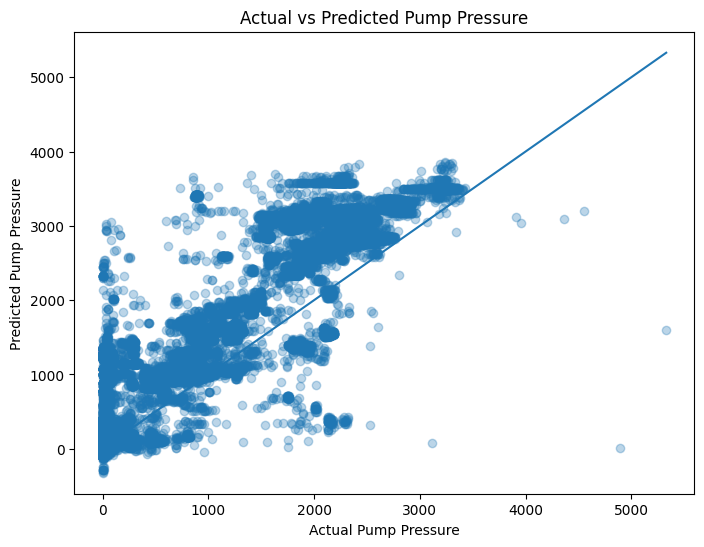

In [ ]:
# Checking Actual vs Predicted Pump Pressure
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_cat, alpha=0.3)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Pump Pressure")
plt.ylabel("Predicted Pump Pressure")
plt.title("Actual vs Predicted Pump Pressure")

plt.show()

### Observation

The Actual vs Predicted plot shows a positive relationship between the actual and predicted Pump Pressure values, indicating that the model captures the general pressure trend. However, the points show considerable deviation from the ideal diagonal line, particularly at higher pressure values. This indicates that the model has difficulty accurately predicting some high-pressure observations.

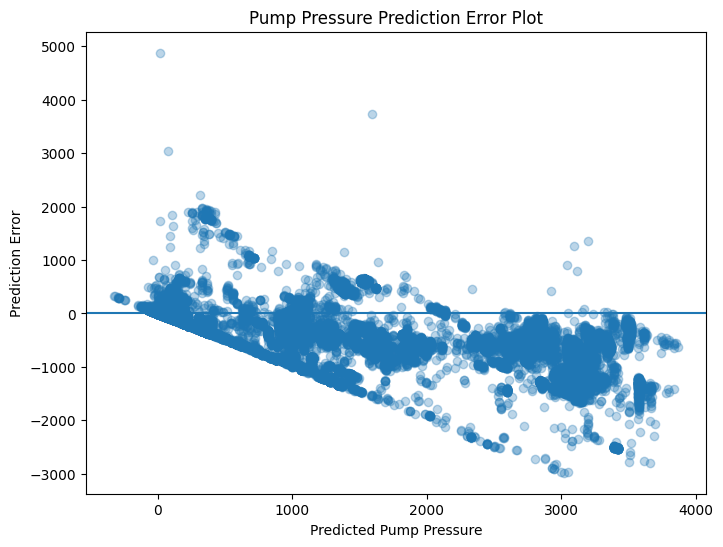

In [43]:
# Calculate prediction errors
errors = y_test - y_pred_cat

plt.figure(figsize=(8, 6))

plt.scatter(y_pred_cat, errors, alpha=0.3)

plt.axhline(y=0)

plt.xlabel("Predicted Pump Pressure")
plt.ylabel("Prediction Error")
plt.title("Pump Pressure Prediction Error Plot")

plt.show()

## Observation

The prediction error plot shows that the errors are not randomly distributed around zero. A clear downward pattern is visible as predicted Pump Pressure increases. This indicates systematic prediction bias, with the model tending to overpredict Pump Pressure at higher predicted values. The plot also contains several large positive and negative errors, showing that some observations are difficult for the model to predict accurately.

Overall, the error analysis indicates that although the CatBoost model provides the best performance among the tested models, there is still room for improvement in prediction accuracy and error consistency.